# Univariate Imputation

## Univariate imputation for numerical data

### 1. Mean/Median replacement

In this technique of univariate imputation (using only the given column's info to replace the missimg values), the missing values rea replaced by the mean/ median of the variable's data. 
In case of normal distribution, mean performs well, but in case of skewed distributions, median is preferred over mean. 

#### Advantages :
1. Simple to implement, hence also easy to recreate on the server

#### Disadvantages :
1. Changes the variable's distribution
2. Changes the covariance/ correlation of the col with the other cols
3. May also introduce outliers to the data

#### When to use ?
- MCAR (Missing Completely At Random)
- missing data < 5% of total 

Not usually preferred though because of the significant disadvantages

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [43]:
df = pd.read_csv('../../3_eda/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
# creating single col family combining sibsp and parch
df['Family'] = df['SibSp'] + df['Parch']
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [45]:
# keeping only the required cols for now
cols = [ 'Age', 'Fare', 'Family', 'Survived']
df = df[cols]
df.sample(5)

,Age,Fare,Family,Survived
551,27.0,26.0000,0,0
687,19.0,10.1708,0,0
390,36.0,120.0000,3,1
701,35.0,26.2875,0,1
28,NaN,7.8792,0,1


In [53]:
import math, random

for i in range(5):
    num = math.floor(random.random()*100)
    print(num)
    df.iloc[num, 1] = np.nan
    
df.head(10)

86
32
35
15
4


,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,NaN,0,0
5,NaN,8.4583,0,0
6,54.0,51.8625,0,0
7,2.0,21.0750,4,0
8,27.0,11.1333,2,1
9,14.0,30.0708,1,1


In [54]:
df.isnull().mean()*100

Age         19.865320
Fare         2.469136
Family       0.000000
Survived     0.000000
dtype: float64

The dataset to apply mean/median replacement has been created

In [55]:
#train-test split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

In [56]:
X_train.isnull().mean()

Age       0.196629
Fare      0.019663
Family    0.000000
dtype: float64

Calculate the mean and median of the age and fare cols 

In [ ]:
#Age col
age_mean = X_train['Age'].mean()
age_median = X_train['Age'].median()

#Fare col
fare_mean = X_train['Fare'].mean()
fare_median = X_train['Fare'].median()

np.float64(29.498846153846156)

In [60]:
# Creating new cols with missing vals replaced by median and mean
X_train['Age_median'] = X_train['Age'].fillna(age_median)
X_train['Age_mean'] = X_train['Age'].fillna(age_mean)

X_train['Fare_median'] = X_train['Age'].fillna(fare_median)
X_train['Fare_mean'] = X_train['Age'].fillna(fare_mean)

In [61]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
451,NaN,19.9667,1,28.0,29.498846,14.4,32.687057
661,40.0,7.2250,0,40.0,40.000000,40.0,40.000000
352,15.0,7.2292,2,15.0,15.000000,15.0,15.000000
399,28.0,12.6500,0,28.0,28.000000,28.0,28.000000
711,NaN,26.5500,0,28.0,29.498846,14.4,32.687057


Stats to check once imputation applied

##### 1. Variance (usually shrinks)

In [ ]:
print("Original Age variable variance : ", X_train['Age'].var())
print("Mean Imputed Age variable variance : ", X_train['Age_mean'].var())
print("Median Imputed Age variable variance : ", X_train['Age_median'].var())

print("Original Fare variable variance : ", X_train['Fare'].var())
print("Mean Imputed Fare variable variance : ", X_train['Fare_mean'].var())
print("Median Imputed Fare variable variance : ", X_train['Fare_median'].var())

Original Age variable variance :  210.2517072477435
Mean Imputed Age variable variance :  168.85193366872227
Median Imputed Age variable variance :  169.20731007048155
Original Fare variable variance :  2743.9510767625343
Mean Imputed Fare variable variance :  170.45986931234458
Median Imputed Fare variable variance :  204.91494514688915


##### 2. distribution of the variable

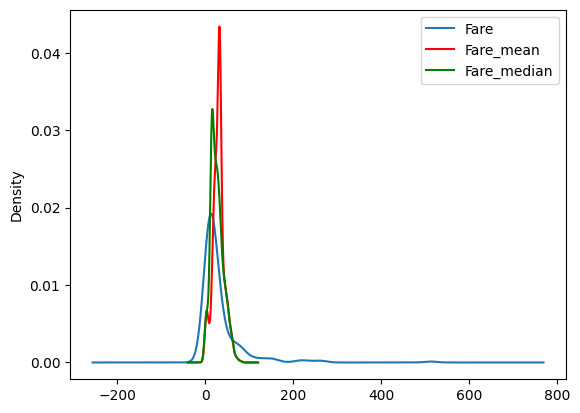

In [67]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# Mean imputed distribution
X_train['Fare_mean'].plot(kind='kde', ax=ax, c='red')

# Median imputed distribution
X_train['Fare_median'].plot(kind='kde', ax=ax, c='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')


Drastic change in distribution - not good

Perform the same for age too

##### 5. covariance & correlation

In [68]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,210.251707,72.460002,-6.993325,210.251707,210.251707,210.251707,210.251707
Fare,72.460002,2743.951077,18.627904,61.876669,58.194652,95.285986,50.362596
Family,-6.993325,18.627904,2.830892,-5.587710,-5.616299,-5.328300,-5.677112
Age_median,210.251707,61.876669,-5.587710,169.207310,168.851934,172.431870,168.096009
Age_mean,210.251707,58.194652,-5.616299,168.851934,168.851934,168.851934,168.851934
Fare_median,210.251707,95.285986,-5.328300,172.431870,168.851934,204.914945,161.237014
Fare_mean,210.251707,50.362596,-5.677112,168.096009,168.851934,161.237014,170.459869


In [69]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.088483,-0.319651,1.000000,1.000000,1.000000,1.000000
Fare,0.088483,1.000000,0.212662,0.090660,0.085348,0.127045,0.073505
Family,-0.319651,0.212662,1.000000,-0.255307,-0.256883,-0.221228,-0.258437
Age_median,1.000000,0.090660,-0.255307,1.000000,0.998949,0.926022,0.989776
Age_mean,1.000000,0.085348,-0.256883,0.998949,1.000000,0.907750,0.995272
Fare_median,1.000000,0.127045,-0.221228,0.926022,0.907750,1.000000,0.862714
Fare_mean,1.000000,0.073505,-0.258437,0.989776,0.995272,0.862714,1.000000


##### 6. Boxplot

<Axes: >

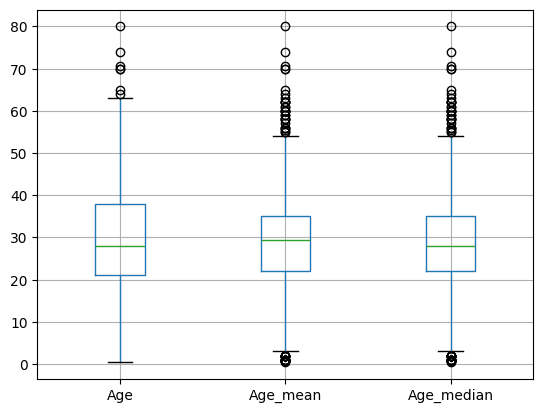

In [70]:
X_train[['Age', 'Age_mean', 'Age_median']].boxplot()

YOU CAN SEE THE NEW OUTLIERS

## Applying Mean/Mean imputation using sklearn

In [71]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
#create imputer transformers
imp1 = SimpleImputer(strategy='median')
imp2 = SimpleImputer(strategy='mean') 

In [73]:
#Applying col transformation
trf = ColumnTransformer([
    ('imp1', imp1, ['Age']),
    ('imp2', imp2, ['Fare'])
], remainder='passthrough')

In [74]:
# fit transformer
trf.fit(X_train)

# Apply the transformer
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [75]:
X_train

array([[ 45.5   ,  28.5   ,   0.    ],
       [ 23.    ,  13.    ,   0.    ],
       [ 32.    ,   7.925 ,   0.    ],
       ...,
       [ 41.    ,  14.1083,   2.    ],
       [ 14.    , 120.    ,   3.    ],
       [ 21.    ,  77.2875,   1.    ]], shape=(712, 3))

### ***Even for transforming the test dataset, mean of the training data would be used***

## Arbitrary Value Imputation

The NaN values are replaced by an arbitrary value, outside of the range of the variable so that the model is able to differentiate between observations with and without the missing values.
Ex- missing values in age col can be replaced by -1.

### Advantages
- Easy and simple

### Disadvantages
- Distorts the PDF
- Changes the variance
- Changes the covariance and correlation with other variables

### When to use?
- When data is **NOT** missing at random

In [76]:
df = pd.read_csv('../../3_eda/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [77]:
# creating single col family combining sibsp and parch
df['Family'] = df['SibSp'] + df['Parch']
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [79]:
# keeping only the required cols for now
cols = [ 'Age', 'Fare', 'Family', 'Survived']
df = df[cols]
df.sample(5)

,Age,Fare,Family,Survived
548,33.0,20.5250,2,0
786,18.0,7.4958,0,1
731,11.0,18.7875,0,0
522,NaN,7.2250,0,0
878,NaN,7.8958,0,0


In [87]:
import math, random

for i in range(5):
    num = math.floor(random.random()*100)
    print(num)
    df.iloc[num, 1] = np.nan
    
df.head(10)

76
79
63
39
4


,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,NaN,0,0
5,NaN,8.4583,0,0
6,54.0,NaN,0,0
7,2.0,21.0750,4,0
8,27.0,11.1333,2,1
9,14.0,30.0708,1,1


In [88]:
df.isnull().mean()*100

Age         19.865320
Fare         2.581369
Family       0.000000
Survived     0.000000
dtype: float64

In [ ]:
#train-test split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)
X_train.isnull().mean()

Age       0.196629
Fare      0.025281
Family    0.000000
dtype: float64

Replacing the missing vals in age and fare cols with -1 & 999 respectively

In [101]:
X_train['Age_minus1'] = X_train['Age'].fillna(-1)
X_train['Fare_999'] = X_train['Fare'].fillna(999)

X_train.sample(7)

,Age,Fare,Family,Age_minus1,Fare_999
22,15.0,8.0292,0,15.0,8.0292
142,24.0,15.8500,1,24.0,15.8500
627,21.0,77.9583,0,21.0,77.9583
729,25.0,7.9250,1,25.0,7.9250
16,2.0,29.1250,5,2.0,29.1250
522,NaN,7.2250,0,-1.0,7.2250
251,29.0,10.4625,2,29.0,10.4625


### Using sklearn

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)
X_train.sample(7)

,Age,Fare,Family
175,18.0,7.8542,2
872,33.0,5.0000,0
559,36.0,17.4000,1
732,NaN,0.0000,0
707,42.0,26.2875,0
365,30.0,7.2500,0
115,21.0,7.9250,0


In [104]:
X_train.isnull().mean()*100

Age       19.662921
Fare       2.528090
Family     0.000000
dtype: float64

In [110]:
# imputer transformers
imputer1 = SimpleImputer(strategy='constant', fill_value=-1)
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

# col transformer object
trf = ColumnTransformer([
    ('imputer1', imputer1,['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [111]:
# fit 
trf.fit(X_train)

# transform
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

Check the stats - pdf, var, cov, corr again

### 3. End of distribution Imputation
In the arbitrary imputation, any random value is used for imputatino, but may not always be the most optimal. SO instead of arbitrary, we specifically use one of the values at any of the ends of the distribution, i.e., outliers. 

In case of normally distributed variable, the val is found as either (mean +3.variance) or (mean - 3.variance)

In case of skewed distribution, the val is found as : (Q1-1.5IQR) or (Q3 - 1.5IQR) where Q1 is the 25th %ile, Q3 is teh 75th %ile and IQR = Q3 - Q1

#### Advantages and Disadvantages 
same as arbitrary imputation

#### when to use ?
same as above